# Trade Under Pressure



## Import packages

In [9]:
%load_ext autoreload
%autoreload 1
%aimport thesis_utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import functools as ft
# Core
import sys

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
# Data analysis, preprocessing and math
import numpy as np
import pandas as pa
# Plotting
import seaborn as sns
from matplotlib.patches import Patch
from sklearn import preprocessing

# Private utilities package
import thesis_utils as tu
import thesis_utils.constants.Constants as Constants

In [11]:
log = tu.set_up_logger(sys.stdout)

## Data preprocessing

### Country codes

In [12]:
codes_df = pa.read_excel("../data/geographic/country_codes.xls",
                         dtype={
                           "CountryCode": object,
                         })
codes_df = tu.clean_codes(codes_df)
codes_df_labels = codes_df["ISO3"]
np.array(codes_df_labels)

array(['ABW', 'AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ATG',
       'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR',
       'BHR', 'BHS', 'BIH', 'BLR', 'BLZ', 'BOL', 'BRA', 'BRB', 'BRN',
       'BTN', 'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR',
       'COL', 'COM', 'CPV', 'CRI', 'CUB', 'CYP', 'CZE', 'DEU', 'DJI',
       'DMA', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ESH', 'ESP', 'EST',
       'ETH', 'EUN', 'FIN', 'FJI', 'FRA', 'FRO', 'FSM', 'GAB', 'GBR',
       'GEO', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'GRC', 'GRD', 'GRL',
       'GTM', 'GUY', 'HKG', 'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IND',
       'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR', 'JPN',
       'KAZ', 'KEN', 'KGZ', 'KHM', 'KIR', 'KNA', 'KOR', 'KWT', 'LAO',
       'LBN', 'LBR', 'LBY', 'LCA', 'LKA', 'LSO', 'LTU', 'LUX', 'LVA',
       'MAR', 'MDA', 'MDG', 'MDV', 'MEX', 'MHL', 'MKD', 'MLI', 'MLT',
       'MMR', 'MNG', 'MOZ', 'MRT', 'MUS', 'MWI', 'MYS', 'NAM', 'NER',
       'NGA', 'NIC',

In [13]:
codes_df

,ISO3,UNDS,Country Name
0,ABW,533,Aruba
1,AFG,004,Afghanistan
2,AGO,024,Angola
4,ALB,008,Albania
6,AND,020,Andorra
...,...,...,...
267,YEM,887,Yemen
268,YUG,890,"Yugoslavia, FR (Serbia/Montene"
269,ZAF,710,South Africa
271,ZMB,894,Zambia



### Dist CEPII

In [14]:
# Loading and preprocessing Dist CEPII dataset
dist_df = pa.read_excel("../data/geographic/dist_cepii.xls",
                        index_col=None, header=0,
                        na_values=[".", "nan", "NaN"], verbose=False, decimal=",",
                        dtype={ "contig": bool, "comlang_off": bool,
                                "comlang_ethno": bool, "colony": bool,
                                "smctry": bool }
                        )
dist_df = tu.clean_cepii(dist_df)

In [15]:
dist_df

,origin,destination,contig,comlang_off,comlang_ethno,colony,smctry,dist,distcap,distw,distwces
0,ABW,ABW,False,False,False,False,False,5.225315,5.225315,25.09354,23.04723
1,ABW,AFG,False,False,False,False,False,13257.810000,13257.810000,13168.22000,13166.37000
2,ABW,AGO,False,False,False,False,False,9516.913000,9516.913000,9587.31600,9584.19300
3,ABW,ALB,False,False,False,False,False,9091.742000,9091.742000,9091.57600,9091.46600
4,ABW,AND,False,True,False,False,False,7572.788000,7572.788000,7570.08400,7570.08300
...,...,...,...,...,...,...,...,...,...,...,...
36476,ZWE,YEM,False,False,False,False,False,3971.474000,3971.474000,4001.15100,3993.17300
36477,ZWE,SER,False,False,False,False,False,7056.402000,7056.402000,7046.43200,7042.83000
36478,ZWE,ZAF,True,True,True,False,False,2186.206000,926.174300,1258.55200,1101.43800
36479,ZWE,ZMB,True,True,True,False,False,396.804100,396.804100,583.79540,525.07340


### GSDB V4 Dyadic

In [16]:
gsdb_df = pa.read_stata("../data/sanctions/GSDB_V4_Dyadic.dta")
gsdb_df = tu.clean_gsdb(gsdb_df)
gsdb_df

,case_id,ISO3,sanctioning_state,sanctioned_state_iso3,sanctioned_state,year,arms,military,trade,descr_trade,financial,travel,other,target_mult,sender_mult,objective,success
0,471,AFG,Afghanistan,AGO,Angola,1993,1,1,1,exp_part,0,0,0,0,1,end_war,success_total
1,471,AFG,Afghanistan,AGO,Angola,1994,1,1,1,exp_part,0,0,0,0,1,end_war,success_total
2,471,AFG,Afghanistan,AGO,Angola,1995,1,1,1,exp_part,0,0,0,0,1,end_war,success_total
3,471,AFG,Afghanistan,AGO,Angola,1996,1,1,1,exp_part,0,0,0,0,1,end_war,success_total
4,"471,574",AFG,Afghanistan,AGO,Angola,1997,1,1,1,exp_part,0,1,1,0,1,"end_war,end_war","success_total,success_total"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159060,"1031,1047",ZWE,Zimbabwe,YEM,"Yemen, North",2019,1,1,0,,1,1,0,0,1,"end_war,terrorism,human_rights,end_war,terrori...","ongoing,ongoing,ongoing,ongoing,ongoing,ongoing"
159061,"1047,1031",ZWE,Zimbabwe,YEM,"Yemen, North",2020,1,1,0,,1,1,0,0,1,"end_war,terrorism,human_rights,end_war,terrori...","ongoing,ongoing,ongoing,ongoing,ongoing,ongoing"
159062,"1031,1047",ZWE,Zimbabwe,YEM,"Yemen, North",2021,1,1,0,,1,1,0,0,1,"end_war,terrorism,human_rights,end_war,terrori...","ongoing,ongoing,ongoing,ongoing,ongoing,ongoing"
159063,"1031,1047",ZWE,Zimbabwe,YEM,"Yemen, North",2022,1,1,0,,1,1,0,0,1,"end_war,terrorism,human_rights,end_war,terrori...","ongoing,ongoing,ongoing,ongoing,ongoing,ongoing"


### GDP Data

In [17]:
gdp_df_raw = pa.read_csv(filepath_or_buffer="../data/economic/GDP(currentUSD)_1974-2023.csv", sep=",",
                         na_values=["..", "nan"])
gdp_df = tu.clean_gdp(gdp_df_raw)
gdp_df

18/08 15:08 - INFO: Missing Threshold: 0.25

18/08 15:08 - INFO: Length before filter: (217, 40)

18/08 15:08 - INFO: Length after filter: (198, 40)



,ISO3,1985,1986,1987,1988,1989,1990,1991,1992,1993,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,ALB,1.897050e+09,2.097326e+09,2.080796e+09,2.051236e+09,2.253090e+09,2.028554e+09,1.099559e+09,6.521750e+08,1.185315e+09,...,1.322815e+10,1.138685e+10,1.186120e+10,1.301973e+10,1.537951e+10,1.558511e+10,1.524146e+10,1.803201e+10,1.901724e+10,2.354718e+10
2,DZA,5.793787e+10,6.369201e+10,6.674582e+10,5.908940e+10,5.563472e+10,6.204851e+10,4.571568e+10,4.800313e+10,4.994558e+10,...,2.389427e+11,1.874939e+11,1.807638e+11,1.898809e+11,1.945545e+11,1.934597e+11,1.648734e+11,1.862312e+11,2.256385e+11,2.476262e+11
4,AND,3.467427e+08,4.819960e+08,6.112999e+08,7.214259e+08,7.954896e+08,1.028990e+09,1.106891e+09,1.209992e+09,1.007090e+09,...,3.271686e+09,2.789881e+09,2.896610e+09,3.000162e+09,3.218420e+09,3.155149e+09,2.891001e+09,3.324648e+09,3.380613e+09,3.785067e+09
5,AGO,7.554065e+09,7.072536e+09,8.084412e+09,8.769837e+09,1.020178e+10,1.122952e+10,1.060378e+10,8.307811e+09,5.768720e+09,...,1.359668e+11,9.049642e+10,5.276162e+10,7.369015e+10,7.945069e+10,7.089796e+10,4.850156e+10,6.650513e+10,1.043997e+11,8.482465e+10
6,ATG,2.463444e+08,2.975370e+08,3.468407e+08,4.113741e+08,4.551481e+08,4.786926e+08,5.043074e+08,5.251037e+08,5.656333e+08,...,1.378830e+09,1.437756e+09,1.489693e+09,1.531152e+09,1.661530e+09,1.725352e+09,1.410796e+09,1.601367e+09,1.867733e+09,2.033085e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,VEN,6.196547e+10,6.051612e+10,4.802903e+10,6.022641e+10,4.353671e+10,4.860695e+10,5.345344e+10,6.041652e+10,6.003746e+10,...,4.823593e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
211,VNM,1.409469e+10,2.633662e+10,3.665811e+10,2.542381e+10,6.293305e+09,6.471741e+09,9.613370e+09,9.866990e+09,1.318095e+10,...,2.334515e+11,2.392583e+11,2.570960e+11,2.813536e+11,3.101065e+11,3.343653e+11,3.466157e+11,3.664748e+11,4.103240e+11,4.297170e+11
214,YEM,NaN,NaN,NaN,NaN,NaN,1.264382e+10,1.466545e+10,1.795937e+10,2.173680e+10,...,4.322859e+10,4.244449e+10,3.131782e+10,2.684223e+10,2.160616e+10,NaN,NaN,NaN,NaN,NaN
215,ZMB,2.252455e+09,1.664414e+09,2.265251e+09,3.728878e+09,3.994673e+09,3.288382e+09,3.376807e+09,3.182811e+09,3.273508e+09,...,2.714102e+10,2.125122e+10,2.095841e+10,2.587360e+10,2.631151e+10,2.330867e+10,1.813776e+10,2.209642e+10,2.916378e+10,2.757796e+10


Check countries that are in CEPII, but not in gdp_df dataset.

In [18]:
countries_unique_to_cepii = list(set(dist_df["origin"].unique()) - set(gdp_df["ISO3"].unique()))
countries_unique_to_cepii

['TWN', 'AFG', 'SMR', 'ESH']

Check countries that are in gdp_df, but not in CEPII dataset.

In [19]:
countries_unique_to_gdp_df = list(set(gdp_df["ISO3"].unique()) - set(dist_df["origin"].unique()))
countries_unique_to_gdp_df

['COD']

### WITS Trade Data
- First, lets define kind of files I can fetch
  - Import:
    - Specific Country with All, yearly
  - Export:
    - Specific Country with All, yearly

---

- Let's load the IMPORT data for each country, final format should be of shape:
  - YEAR | REPORTER_ISO3 | PARTNER_ISO3 | IMPORT_VALUE

In [20]:
codes_df_stripped = codes_df.copy(deep=True)
codes_df_stripped["Country Name"] = codes_df["Country Name"].str.strip().str.lower()
country_to_code_dict = dict(zip(codes_df_stripped["Country Name"], codes_df_stripped["ISO3"]))

In [21]:
import_albania = pa.read_excel("../data/trade/import/IMPORT_ALB.xlsx")
import_albania["Partner Name"] = import_albania["Partner Name"].str.strip().str.lower()
import_albania["Partner Name"] = import_albania["Partner Name"].map(country_to_code_dict).fillna(
  import_albania["Partner Name"])
import_albania

,Reporter Name,Partner Name,Trade Flow,Product Group,Indicator,1988,1989,1990,1991,1992,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Albania,WLD,Import,All Products,Import (US$ Thousand),NaN,NaN,NaN,NaN,NaN,...,5229972.238,4320219.367,4669289.913,5.293902e+06,5.941287e+06,5.908003e+06,5.410943e+06,7.734905e+06,8.407345e+06,NaN
1,Albania,AFG,Import,All Products,Import (US$ Thousand),NaN,NaN,NaN,NaN,NaN,...,10.888,6.941,0.556,2.419140e-01,4.625900e+01,4.339686e-01,NaN,3.127410e-01,NaN,NaN
2,Albania,DZA,Import,All Products,Import (US$ Thousand),NaN,NaN,NaN,NaN,NaN,...,15559.606,6380.700,9294.404,1.911840e+04,2.123983e+04,4.856517e+03,2.170483e+04,6.894285e+04,8.873554e+04,NaN
3,Albania,american samoa,Import,All Products,Import (US$ Thousand),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.481,2.401000e-03,2.013671e-01,NaN,5.164654e-01,4.619527e+00,NaN,NaN
4,Albania,AND,Import,All Products,Import (US$ Thousand),NaN,NaN,NaN,NaN,NaN,...,4.032,NaN,28.980,3.268500e-02,NaN,2.914634e-01,NaN,3.097673e+01,2.338670e+01,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,Albania,wallis and futura isl.,Import,All Products,Import (US$ Thousand),NaN,NaN,NaN,NaN,NaN,...,0.030,NaN,0.393,NaN,NaN,3.779932e-02,NaN,4.395000e-03,NaN,NaN
232,Albania,ESH,Import,All Products,Import (US$ Thousand),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233,Albania,YEM,Import,All Products,Import (US$ Thousand),NaN,NaN,NaN,NaN,NaN,...,0.425,1.002,NaN,NaN,4.778572e+00,2.232645e-01,6.268289e-01,7.901360e-01,NaN,NaN
234,Albania,ZMB,Import,All Products,Import (US$ Thousand),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.970011e-01,NaN,4.172110e-02,9.407101e+00,NaN,NaN




## Collect and analyze country labels in all the data sets

### DIST CEPII Labels

In [22]:
dist_labels_origin = dist_df["origin"].unique()
log.info(len(dist_labels_origin))
dist_labels_origin

18/08 15:08 - INFO: 191



array(['ABW', 'AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ATG',
       'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR',
       'BHR', 'BHS', 'BIH', 'BLR', 'BLZ', 'BOL', 'BRA', 'BRB', 'BRN',
       'BTN', 'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR',
       'COL', 'COM', 'CPV', 'CRI', 'CUB', 'CYP', 'CZE', 'DEU', 'DJI',
       'DMA', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ESH', 'ESP', 'EST',
       'ETH', 'FIN', 'FJI', 'FRA', 'FRO', 'FSM', 'GAB', 'GBR', 'GEO',
       'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'GRC', 'GRD', 'GRL', 'GTM',
       'GUY', 'HKG', 'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IND', 'IRL',
       'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR', 'JPN', 'KAZ',
       'KEN', 'KGZ', 'KHM', 'KIR', 'KNA', 'KOR', 'KWT', 'LAO', 'LBN',
       'LBR', 'LBY', 'LCA', 'LKA', 'LSO', 'LTU', 'LUX', 'LVA', 'MAR',
       'MDA', 'MDG', 'MDV', 'MEX', 'MHL', 'MKD', 'MLI', 'MLT', 'MMR',
       'MNG', 'MOZ', 'MRT', 'MUS', 'MWI', 'MYS', 'NAM', 'NER', 'NGA',
       'NIC', 'NLD',

In [23]:
dist_labels_dest = dist_df["destination"].unique()
log.info(len(dist_labels_dest))
dist_labels_dest

18/08 15:08 - INFO: 191



array(['ABW', 'AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ATG',
       'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR',
       'BHR', 'BHS', 'BIH', 'BLR', 'BLZ', 'BOL', 'BRA', 'BRB', 'BRN',
       'BTN', 'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR',
       'COL', 'COM', 'CPV', 'CRI', 'CUB', 'CYP', 'CZE', 'DEU', 'DJI',
       'DMA', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ESH', 'ESP', 'EST',
       'ETH', 'FIN', 'FJI', 'FRA', 'FRO', 'FSM', 'GAB', 'GBR', 'GEO',
       'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'GRC', 'GRD', 'GRL', 'GTM',
       'GUY', 'HKG', 'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IND', 'IRL',
       'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR', 'JPN', 'KAZ',
       'KEN', 'KGZ', 'KHM', 'KIR', 'KNA', 'KOR', 'KWT', 'LAO', 'LBN',
       'LBR', 'LBY', 'LCA', 'LKA', 'LSO', 'LTU', 'LUX', 'LVA', 'MAR',
       'MDA', 'MDG', 'MDV', 'MEX', 'MHL', 'MKD', 'MLI', 'MLT', 'MMR',
       'MNG', 'MOZ', 'MRT', 'MUS', 'MWI', 'MYS', 'NAM', 'NER', 'NGA',
       'NIC', 'NLD',

In [24]:
# Check if there are any differences
dist_labels_check = np.array(dist_labels_origin == dist_labels_dest)
log.info("Any false: {}", np.any(~dist_labels_check))

18/08 15:08 - INFO: Any false: False



In [25]:
# Sanity check
log.info("Sum of TRUE values: {}", sum(dist_labels_check))
log.info("Length of ALL values: {}", len(dist_labels_check))

18/08 15:08 - INFO: Sum of TRUE values: 191

18/08 15:08 - INFO: Length of ALL values: 191



In [26]:
dist_labels = dist_labels_origin

### GSDB Labels

In [27]:
gsdb_sanctioning_labels = gsdb_df["ISO3"].unique()
gsdb_sanctioned_labels = gsdb_df["sanctioned_state_iso3"].unique()

In [28]:
gsdb_labels = np.union1d(gsdb_sanctioned_labels, gsdb_sanctioning_labels)
log.info("Total numbers of GSDB labels: {}", len(gsdb_labels))

18/08 15:08 - INFO: Total numbers of GSDB labels: 188



### GDP Labels

In [29]:
gdp_df_labels = gdp_df["ISO3"].unique()
gdp_df_labels

array(['ALB', 'DZA', 'AND', 'AGO', 'ATG', 'ARG', 'ARM', 'ABW', 'AUS',
       'AUT', 'AZE', 'BHS', 'BHR', 'BGD', 'BRB', 'BLR', 'BEL', 'BLZ',
       'BEN', 'BTN', 'BOL', 'BIH', 'BWA', 'BRA', 'BRN', 'BGR', 'BFA',
       'BDI', 'CPV', 'KHM', 'CMR', 'CAN', 'CAF', 'TCD', 'CHL', 'CHN',
       'COL', 'COM', 'COD', 'CRI', 'CIV', 'HRV', 'CUB', 'CYP', 'CZE',
       'DNK', 'DJI', 'DMA', 'DOM', 'ECU', 'EGY', 'SLV', 'GNQ', 'EST',
       'SWZ', 'ETH', 'FRO', 'FJI', 'FIN', 'FRA', 'GAB', 'GMB', 'GEO',
       'DEU', 'GHA', 'GRC', 'GRL', 'GRD', 'GTM', 'GIN', 'GNB', 'GUY',
       'HTI', 'HND', 'HKG', 'HUN', 'ISL', 'IND', 'IDN', 'IRN', 'IRQ',
       'IRL', 'ISR', 'ITA', 'JAM', 'JPN', 'JOR', 'KAZ', 'KEN', 'KIR',
       'KOR', 'KWT', 'KGZ', 'LAO', 'LVA', 'LBN', 'LSO', 'LBR', 'LBY',
       'LTU', 'LUX', 'MDG', 'MWI', 'MYS', 'MDV', 'MLI', 'MLT', 'MHL',
       'MRT', 'MUS', 'MEX', 'FSM', 'MDA', 'MNG', 'MAR', 'MOZ', 'MMR',
       'NAM', 'NRU', 'NPL', 'NLD', 'NZL', 'NIC', 'NER', 'NGA', 'MKD',
       'NOR', 'OMN',

### Intersection labels
Countries that are going to be used for the final data set

In [30]:
log.info("Number of DIST CEPII labels: {}", len(dist_labels))
log.info("Number of GSDB labels: {}", len(gsdb_labels))
log.info("Number of GDP labels: {}", len(gdp_df_labels))
log.info("Number of Country Codes labels: {}", len(codes_df_labels))

label_arrays = [dist_labels, gsdb_labels, gdp_df_labels, codes_df_labels]

intersection_labels = ft.reduce(np.intersect1d, label_arrays)

log.info("Total number of intersect labels: {}", len(intersection_labels))

18/08 15:08 - INFO: Number of DIST CEPII labels: 191

18/08 15:08 - INFO: Number of GSDB labels: 188

18/08 15:08 - INFO: Number of GDP labels: 188

18/08 15:08 - INFO: Number of Country Codes labels: 194

18/08 15:08 - INFO: Total number of intersect labels: 183



## Combine Data Sets
Merge the existing data sets into combined data sets for data exploration

In [31]:
records = tu.clean_trade(intersection_labels, codes_df)

In [32]:
Constants.START_YEAR

1985

In [33]:
final_dataset = tu.merge_datasets(codes=codes_df, intersection_labels=intersection_labels, gdp=gdp_df, dist=dist_df,
                                  records=records, gsdb=gsdb_df)
# Save dataset
final_dataset.to_parquet(path=f"ºº../data/model/processed{Constants.START_YEAR}-{Constants.END_YEAR}.parquet",
                         engine="fastparquet")
# final_dataset.to_csv(path_or_buf="../data/model/processed.csv")
final_dataset

,ISO3_reporter,UNDS_reporter,CNAME_reporter,ISO3_partner,UNDS_partner,CNAME_partner,Year,GDP_reporter,GDP_partner,contig,...,arms,military,trade,descr_trade,financial,travel,other,target_mult,sender_mult,GDP_yearly_average
0,AGO,024,Angola,ALB,008,Albania,1985,7.554065e+09,1.897050e+09,False,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,0.0,7.866259e+10
1,AGO,024,Angola,ALB,008,Albania,1986,7.072536e+09,2.097326e+09,False,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,0.0,9.333530e+10
2,AGO,024,Angola,ALB,008,Albania,1987,8.084412e+09,2.080796e+09,False,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,0.0,1.029450e+11
3,AGO,024,Angola,ALB,008,Albania,1988,8.769837e+09,2.051236e+09,False,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,0.0,1.169913e+11
4,AGO,024,Angola,ALB,008,Albania,1989,1.020178e+10,2.253090e+09,False,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,0.0,1.220728e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298962,ZWE,716,Zimbabwe,ZMB,894,Zambia,2019,2.571741e+10,2.330867e+10,True,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,0.0,4.796545e+11
1298963,ZWE,716,Zimbabwe,ZMB,894,Zambia,2020,2.686794e+10,1.813776e+10,True,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,0.0,4.664265e+11
1298964,ZWE,716,Zimbabwe,ZMB,894,Zambia,2021,2.724052e+10,2.209642e+10,True,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,0.0,5.345085e+11
1298965,ZWE,716,Zimbabwe,ZMB,894,Zambia,2022,3.278975e+10,2.916378e+10,True,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,0.0,5.561433e+11


## Data Visualization

### Analyze GDP

In [34]:
# TODO: Move "Data Visualization" in separate Notebook
# Inner join GDP and Country Names on ISO3
gdp_df_countries = pa.merge(
  gdp_df[gdp_df["ISO3"].isin(intersection_labels)],
  codes_df[codes_df["ISO3"].isin(intersection_labels)]
  , on="ISO3", how="inner", validate="m:m")

In [35]:
gdp_df_countries

,ISO3,1985,1986,1987,1988,1989,1990,1991,1992,1993,...,2016,2017,2018,2019,2020,2021,2022,2023,UNDS,Country Name
0,ALB,1.897050e+09,2.097326e+09,2.080796e+09,2.051236e+09,2.253090e+09,2.028554e+09,1.099559e+09,6.521750e+08,1.185315e+09,...,1.186120e+10,1.301973e+10,1.537951e+10,1.558511e+10,1.524146e+10,1.803201e+10,1.901724e+10,2.354718e+10,008,Albania
1,DZA,5.793787e+10,6.369201e+10,6.674582e+10,5.908940e+10,5.563472e+10,6.204851e+10,4.571568e+10,4.800313e+10,4.994558e+10,...,1.807638e+11,1.898809e+11,1.945545e+11,1.934597e+11,1.648734e+11,1.862312e+11,2.256385e+11,2.476262e+11,012,Algeria
2,AND,3.467427e+08,4.819960e+08,6.112999e+08,7.214259e+08,7.954896e+08,1.028990e+09,1.106891e+09,1.209992e+09,1.007090e+09,...,2.896610e+09,3.000162e+09,3.218420e+09,3.155149e+09,2.891001e+09,3.324648e+09,3.380613e+09,3.785067e+09,020,Andorra
3,AGO,7.554065e+09,7.072536e+09,8.084412e+09,8.769837e+09,1.020178e+10,1.122952e+10,1.060378e+10,8.307811e+09,5.768720e+09,...,5.276162e+10,7.369015e+10,7.945069e+10,7.089796e+10,4.850156e+10,6.650513e+10,1.043997e+11,8.482465e+10,024,Angola
4,ATG,2.463444e+08,2.975370e+08,3.468407e+08,4.113741e+08,4.551481e+08,4.786926e+08,5.043074e+08,5.251037e+08,5.656333e+08,...,1.489693e+09,1.531152e+09,1.661530e+09,1.725352e+09,1.410796e+09,1.601367e+09,1.867733e+09,2.033085e+09,028,Antigua and Barbuda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,VEN,6.196547e+10,6.051612e+10,4.802903e+10,6.022641e+10,4.353671e+10,4.860695e+10,5.345344e+10,6.041652e+10,6.003746e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,862,Venezuela
179,VNM,1.409469e+10,2.633662e+10,3.665811e+10,2.542381e+10,6.293305e+09,6.471741e+09,9.613370e+09,9.866990e+09,1.318095e+10,...,2.570960e+11,2.813536e+11,3.101065e+11,3.343653e+11,3.466157e+11,3.664748e+11,4.103240e+11,4.297170e+11,704,Vietnam
180,YEM,NaN,NaN,NaN,NaN,NaN,1.264382e+10,1.466545e+10,1.795937e+10,2.173680e+10,...,3.131782e+10,2.684223e+10,2.160616e+10,NaN,NaN,NaN,NaN,NaN,887,Yemen
181,ZMB,2.252455e+09,1.664414e+09,2.265251e+09,3.728878e+09,3.994673e+09,3.288382e+09,3.376807e+09,3.182811e+09,3.273508e+09,...,2.095841e+10,2.587360e+10,2.631151e+10,2.330867e+10,1.813776e+10,2.209642e+10,2.916378e+10,2.757796e+10,894,Zambia


In [36]:
sns.set_theme()
sns.color_palette("colorblind")

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [37]:
gdp_df_year_values = gdp_df_countries[gdp_df_countries.columns.difference(["ISO3", "Country Name", "UNDS"])]
gdp_df_logs = np.log(gdp_df_year_values)
gdp_df_scaled = gdp_df_year_values.apply(
  lambda col: preprocessing.MinMaxScaler().fit_transform(col.values.reshape(-1, 1)).flatten()
)

In [38]:
gdp_df_logs

,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,21.363566,21.463929,21.456016,21.441708,21.535568,21.430589,20.818175,20.295823,20.893275,21.355043,...,23.305613,23.155725,23.196538,23.289731,23.456302,23.469581,23.447285,23.615414,23.668612,23.882272
1,24.782637,24.877325,24.924157,24.802317,24.742073,24.851182,24.545707,24.594532,24.634200,24.473785,...,26.199489,25.957012,25.920457,25.969663,25.993978,25.988335,25.828444,25.950255,26.142200,26.235186
2,19.664094,19.993446,20.231098,20.396740,20.494468,20.751843,20.824821,20.913880,20.730331,20.740658,...,21.908571,21.749265,21.786807,21.821932,21.892156,21.872302,21.784869,21.924629,21.941323,22.054330
3,22.745352,22.679485,22.813204,22.894584,23.045828,23.141811,23.084477,22.840462,22.475716,22.213542,...,25.635677,25.228576,24.689050,25.023135,25.098402,24.984508,24.604862,24.920545,25.371493,25.163852
4,19.322241,19.511049,19.664376,19.835014,19.936134,19.986569,20.038697,20.079106,20.153457,20.253345,...,21.044501,21.086349,21.121836,21.149286,21.231004,21.268697,21.067420,21.194123,21.347991,21.432820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,24.849843,24.826176,24.595072,24.821377,24.496870,24.607032,24.702077,24.824528,24.818235,24.790901,...,26.901955,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179,23.369064,23.994226,24.324900,23.958952,22.562752,22.590711,22.986421,23.012461,23.302039,23.513598,...,26.176240,26.200810,26.272715,26.362878,26.460182,26.535500,26.571483,26.627195,26.740213,26.786393
180,NaN,NaN,NaN,NaN,NaN,23.260435,23.408760,23.611378,23.802273,24.056166,...,24.489768,24.471463,24.167453,24.013242,23.796244,NaN,NaN,NaN,NaN,NaN
181,21.535286,21.232739,21.540951,22.039373,22.108228,21.913661,21.940196,21.881031,21.909128,22.019857,...,24.024312,23.779680,23.765806,23.976489,23.993272,23.872091,23.621262,23.818681,24.096193,24.040283


In [39]:
gdp_df_operation = gdp_df_logs
gdp_df_max = gdp_df_operation.max()
gdp_df_min = gdp_df_operation.min()
gdp_df_mean = gdp_df_operation.mean()
gdp_df_missing = gdp_df_operation.isna().sum()
gdp_df_stats = {
  "Year": gdp_df_logs.columns,
  "Max": gdp_df_max.values,
  "Q.75": gdp_df_operation.quantile(q=0.75).values,
  "Mean": gdp_df_mean.values,
  "Q.25": gdp_df_operation.quantile(q=0.25).values,
  "Min": gdp_df_min.values,
  # "Missing": gdp_df_missing.values,
}
gdp_df_stats = pa.DataFrame(data=gdp_df_stats)
gdp_df_stats = gdp_df_stats.sort_values("Year").reset_index(drop=True)
gdp_df_stats["Year"] = gdp_df_stats["Year"].astype(int)

In [40]:
long_stats = pa.melt(gdp_df_stats, id_vars="Year",
                     var_name="Measure", value_name="Value")
long_stats

,Year,Measure,Value
0,1985,Max,29.098660
1,1986,Max,29.152640
2,1987,Max,29.211075
3,1988,Max,29.286663
4,1989,Max,29.361185
...,...,...,...
190,2019,Min,17.806773
191,2020,Min,17.761869
192,2021,Min,17.913123
193,2022,Min,17.894166


<Axes: xlabel='Value', ylabel='Count'>

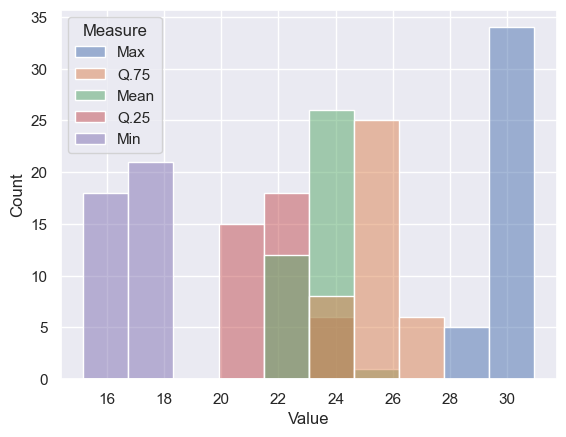

In [41]:
sns.histplot(data=long_stats, x="Value", hue="Measure")

In [42]:
def calculate_yearly_change(column_name):
  previous = gdp_df_stats[column_name].shift(1)
  current = gdp_df_stats[column_name]

  change_percent = ((current[1:].values - previous[1:].values) / current[1:].values) * 100
  change_percent = pa.Series(change_percent).round(5)
  return change_percent


# Compute change from previous year (1975 has 1974 as "previous year")
yearly_change_percentage = pa.DataFrame({
  "Year": gdp_df_stats["Year"][1:].values,
  "%-Change-Max": calculate_yearly_change("Max"),
  "%-Change-Min": calculate_yearly_change("Min"),
  "%-Change-Mean": calculate_yearly_change("Mean"),
  # "%-Change-Q.25": calculate_yearly_change("Q.25"),
  # "%-Change-Q.75": calculate_yearly_change("Q.75"),
})

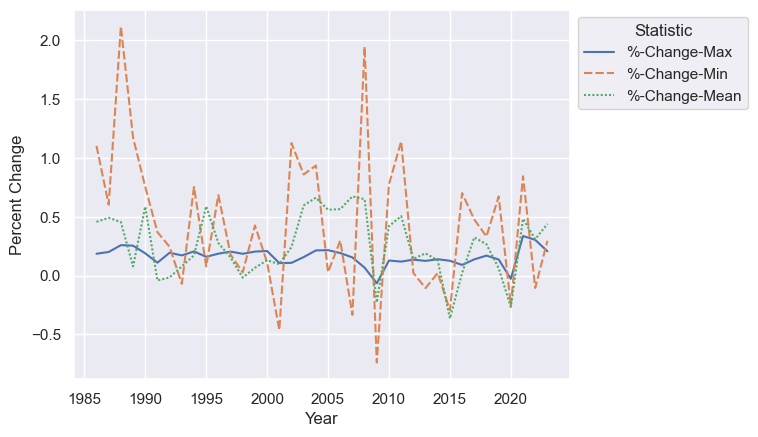

In [43]:
long_yearly = pa.melt(yearly_change_percentage, id_vars="Year",
                      var_name="Statistic", value_name="Percent Change")

line_plot = sns.lineplot(
  data=long_yearly, x="Year", y="Percent Change", hue="Statistic", style="Statistic"
)

sns.move_legend(
  line_plot,
  "upper left",
  bbox_to_anchor=(1, 1)
)

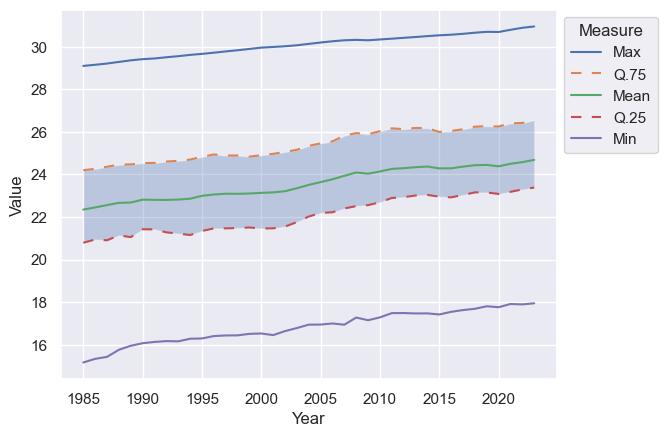

In [44]:
custom_dashes = {
  "Mean": "",
  "Q.75": (5, 5),
  "Q.25": (5, 5),
  "Max": "",
  "Min": "",
}

gdp_df_plt = sns.lineplot(
  data=long_stats,
  x="Year",
  y="Value",
  hue="Measure",
  style="Measure",
  dashes=custom_dashes
)

sns.move_legend(
  gdp_df_plt,
  "upper left",
  bbox_to_anchor=(1, 1)
)

mean_df = long_stats[long_stats["Measure"] == "Mean"]
q25_df = long_stats[long_stats["Measure"] == "Q.25"]
q75_df = long_stats[long_stats["Measure"] == "Q.75"]

plt.fill_between(
  x=mean_df["Year"],
  y1=q25_df["Value"],
  y2=q75_df["Value"],
  alpha=0.3
)

### Analyse Sanctions

In [45]:
gsdb_labels = np.union1d(gsdb_sanctioned_labels, gsdb_sanctioning_labels)

In [46]:
gsdb_countries = pa.merge(
  gsdb_df[gsdb_df["ISO3"].isin(intersection_labels)],
  codes_df[codes_df["ISO3"].isin(intersection_labels)]
  , on="ISO3", how="inner", validate="m:1")

In [47]:
# TODO: Redownload .shx shape file
SHAPEFILE = "../data/countries/ne_10m_admin_0_countries.shx"

In [48]:
geo_df = gpd.read_file(SHAPEFILE)[["ADM0_A3", "geometry", "ADMIN"]]
geo_df = tu.clean_geopa(geo_df, drop_intersection=False)

In [49]:
counts = gsdb_countries["ISO3"].value_counts()

In [50]:
merged_df = pa.merge(geo_df, counts, on="ISO3", how="outer", validate="m:m")
# merged_df = merged_df.fillna(0)

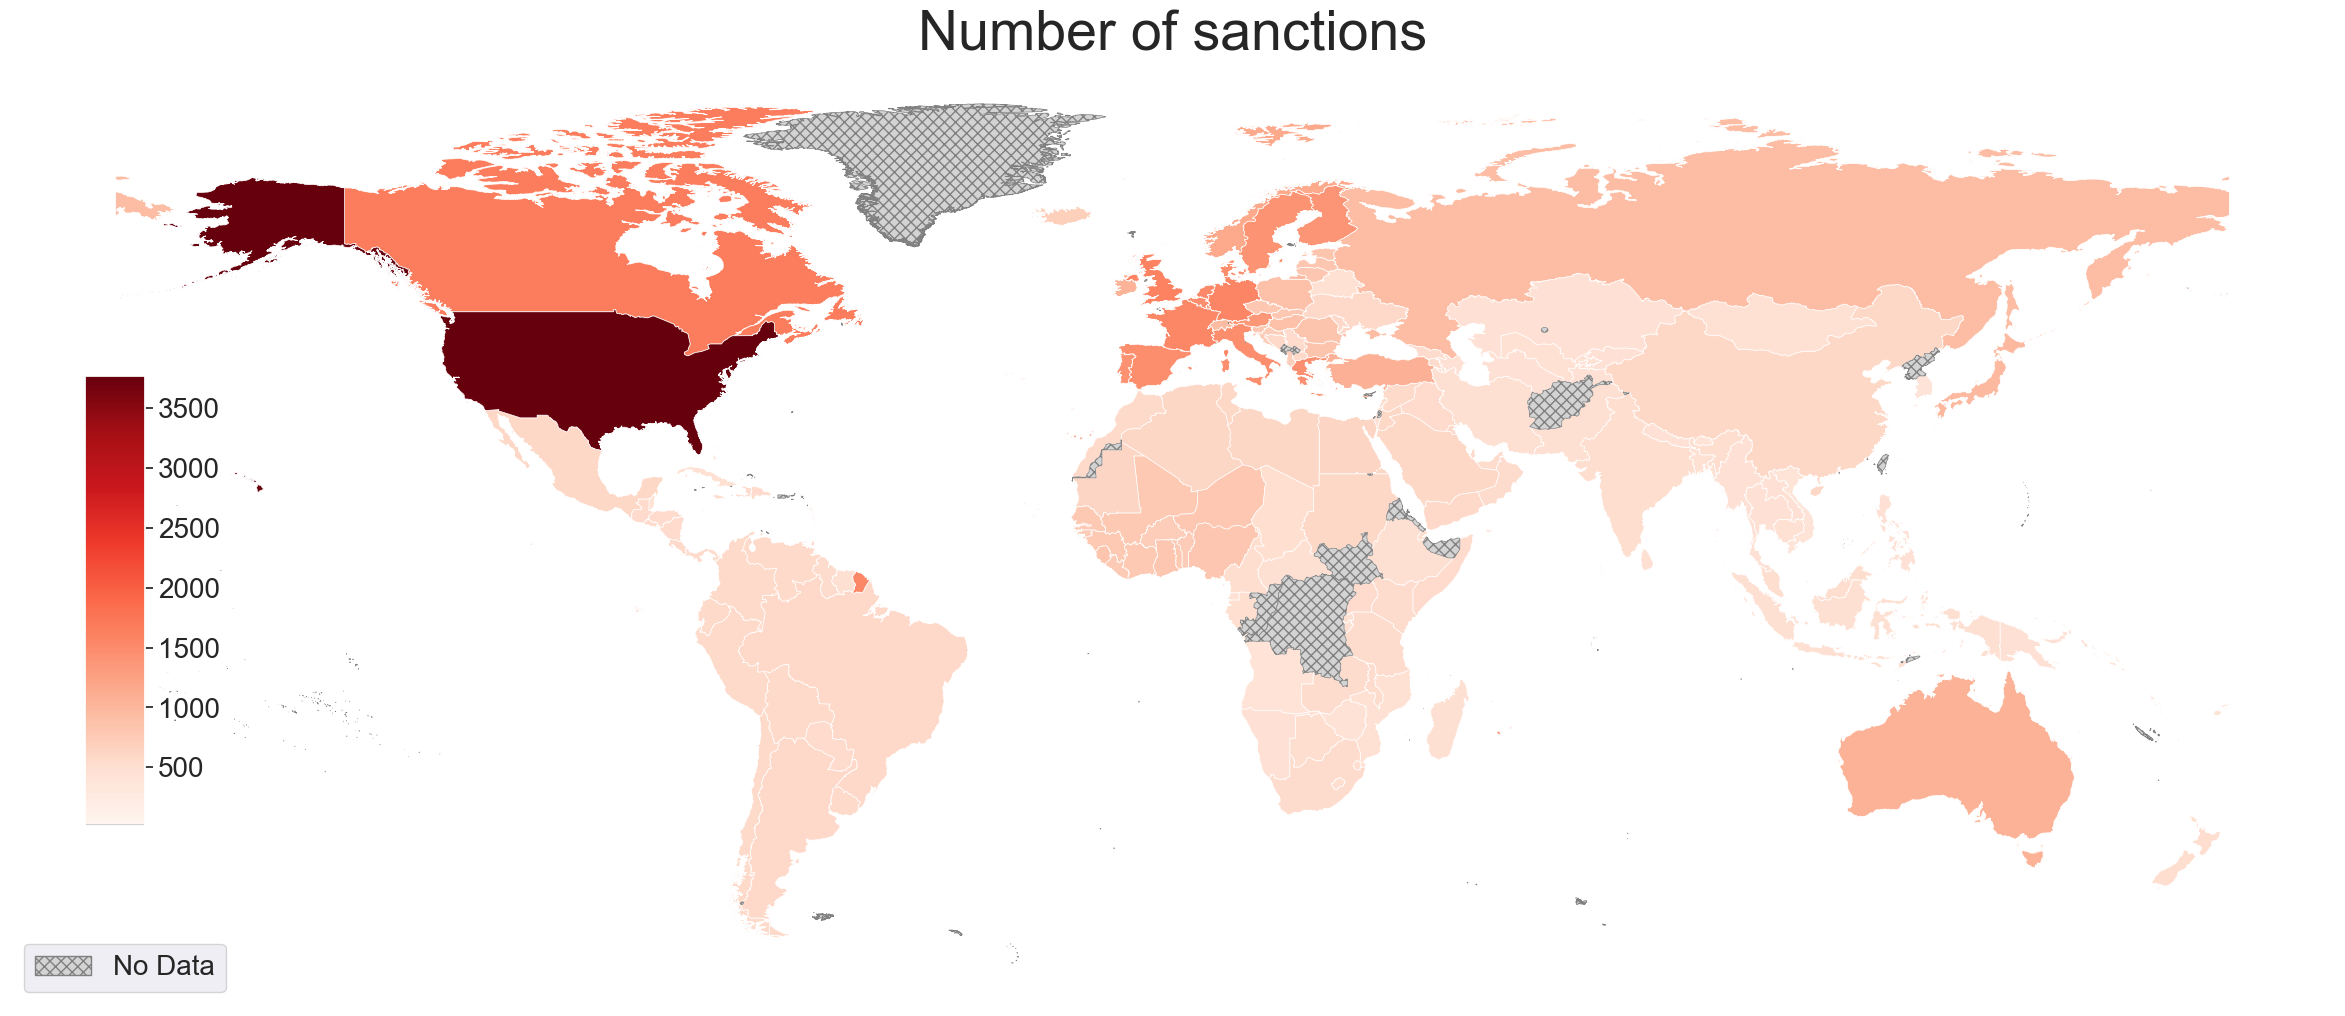

In [51]:
title = "Number of sanctions"

positive_cmap = plt.cm.Reds

colors = ["lightgrey"] + [positive_cmap(i) for i in range(1, positive_cmap.N)]
cmap = mcolors.ListedColormap(colors)

vmin = merged_df["count"].min()
vmax = merged_df["count"].max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(1, figsize=(30, 15))
ax.axis("off")
merged_df.plot(column="count", ax=ax, edgecolor="1", linewidth=0.5, cmap=cmap,
               missing_kwds={
                 "color": "lightgrey",
                 "edgecolor": "grey",
                 "hatch": "xxx",
               })
ax.set_title(title, fontdict={ "fontsize": "40", "fontweight": "5" })

sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
sm._A = []
cbaxes = fig.add_axes([0.15, 0.30, 0.02, 0.3])
cbar = fig.colorbar(sm, cax=cbaxes)
cbar.ax.tick_params(labelsize=20)
legend_elements = [Patch(facecolor="lightgrey", edgecolor="grey", label="No Data", hatch="xxx")]
ax.legend(handles=legend_elements, loc="lower left", fontsize=20)

plt.show()

In [52]:
# Cool Exploration Map
# merged_df.explore(
#   column="count",
#   popup=True,
#   tiles="CartoDB positron",
#   cmap="Reds",
#   missing_kwds=
#   {
#     "color": "grey",
#     "label": "Missing Values"
#   }
# )

In [53]:
dummy_columns = ["arms", "military", "trade", "financial", "travel", "other"]
active_sanctions_yearly = gsdb_df.groupby("year")[dummy_columns].sum().reset_index()
active_sanctions_yearly = pa.melt(active_sanctions_yearly, id_vars="year", value_vars=dummy_columns,
                                  var_name="Category",
                                  value_name="Count")

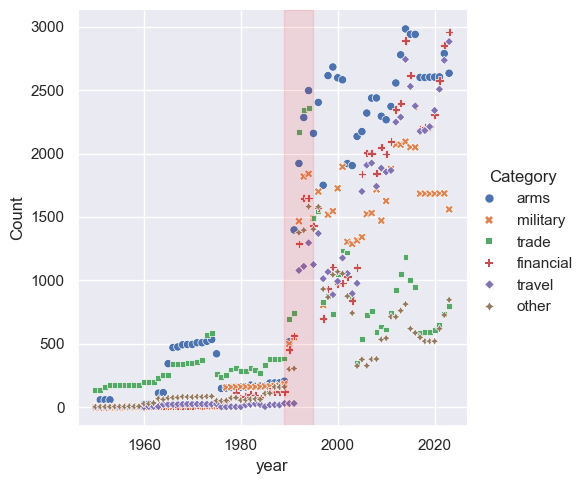

In [54]:
sanctions_categories_plt = sns.relplot(
  data=active_sanctions_yearly,
  x="year",
  y="Count",
  hue="Category",
  style="Category",
)

ax = sanctions_categories_plt.ax
war_period = ax.axvspan(1989, 1995, color='red', alpha=0.1, label="War period")

plt.show()

### CEPII DIST analysis

#### Country-Continent list
Load the list that binds each country to 1 continent. _(Exceptions for duplicates: Russia, Azerbaijan, Armenia, Georgia, Turkey, Cyprus)_

In [55]:
country_continent_list = pa.read_csv("../data/geographic/country-continent.csv", keep_default_na=False)[
  ["Continent_Name", "Continent_Code", "Three_Letter_Country_Code"]]
# country_continent_list = country_continent_list.dropna(ignore_index=True)
country_continent_list = country_continent_list.rename(columns={ "Three_Letter_Country_Code": "ISO3" })
for key in tu.Constants.REPLACE_COUNTRY.keys():
  for value in tu.Constants.REPLACE_COUNTRY[key]["values"]:
    country_continent_list = country_continent_list.replace(value, key)
country_continent_list = country_continent_list[country_continent_list["ISO3"].isin(intersection_labels)]

Split CEPII DIST into continent sets

**Continent codes:**
- EUROPE: EU
- ASIA: AS
- AFRICA: AF
- NORTH AMERICA: NA
- SOUTH AMERICA: SA
- OCEANIA: OC

In [56]:
countries_europe = country_continent_list[country_continent_list["Continent_Code"] == "EU"]["ISO3"]
countries_africa = country_continent_list[country_continent_list["Continent_Code"] == "AF"]["ISO3"]
countries_america = country_continent_list[country_continent_list["Continent_Code"].isin(["NA", "SA"])]["ISO3"]
countries_asia = country_continent_list[country_continent_list["Continent_Code"] == "AS"]["ISO3"]
countries_oceania = country_continent_list[country_continent_list["Continent_Code"] == "OC"]["ISO3"]

In [57]:
dist_europe = dist_df[
  dist_df["origin"].isin(countries_europe) & dist_df["destination"].isin(countries_europe)
  ][["dist", "distcap", "distw"]]
dist_europe = pa.melt(dist_europe, var_name="distance_type", value_name="val")
dist_europe["Continent"] = "Europe"

dist_asia = dist_df[
  dist_df["origin"].isin(countries_asia) & dist_df["destination"].isin(countries_asia)
  ][["dist", "distcap", "distw"]]
dist_asia = pa.melt(dist_asia, var_name="distance_type", value_name="val")
dist_asia["Continent"] = "Asia"

dist_america = dist_df[
  dist_df["origin"].isin(countries_america) & dist_df["destination"].isin(countries_america)
  ][["dist", "distcap", "distw"]]
dist_america = pa.melt(dist_america, var_name="distance_type", value_name="val")
dist_america["Continent"] = "America"

dist_africa = dist_df[
  dist_df["origin"].isin(countries_africa) & dist_df["destination"].isin(countries_africa)
  ][["dist", "distcap", "distw"]]
dist_africa = pa.melt(dist_africa, var_name="distance_type", value_name="val")
dist_africa["Continent"] = "Africa"

dist_oceania = dist_df[
  dist_df["origin"].isin(countries_oceania) & dist_df["destination"].isin(countries_oceania)
  ][["dist", "distcap", "distw"]]
dist_oceania = pa.melt(dist_oceania, var_name="distance_type", value_name="val")
dist_oceania["Continent"] = "Oceania"

In [58]:
merged_dist = pa.concat([dist_asia, dist_europe, dist_africa, dist_america, dist_oceania], axis=0, ignore_index=True)
merged_dist = merged_dist.rename(columns={ "distance_type": "Type", "val": "Distance" })

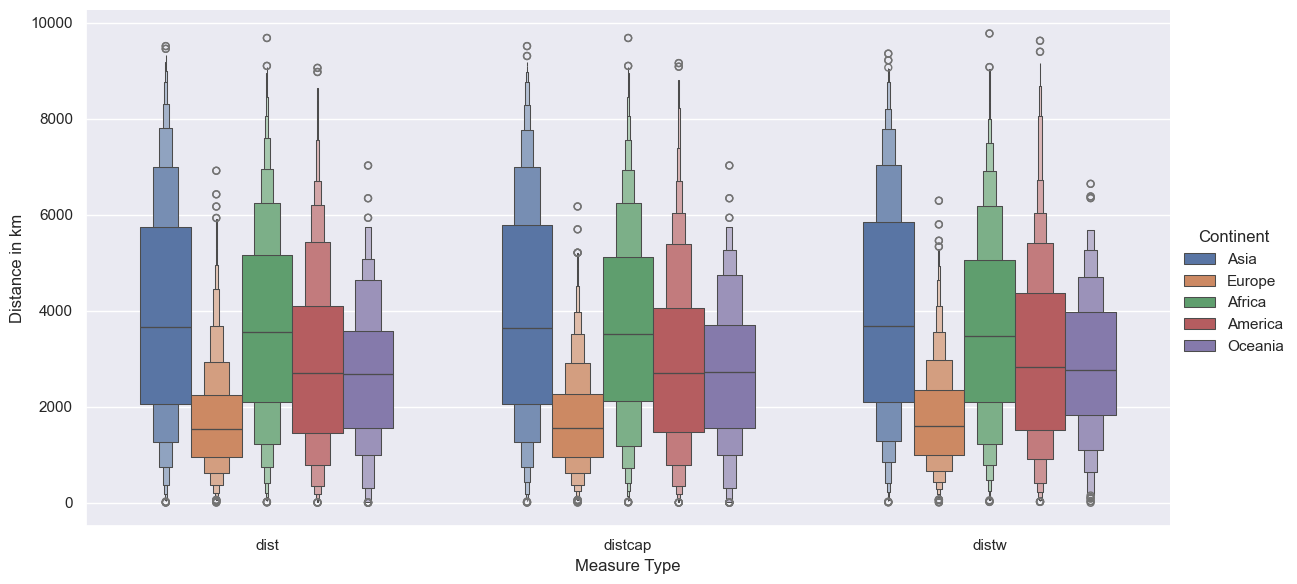

In [59]:
distances_plt = sns.catplot(data=merged_dist, x="Type", y="Distance", hue="Continent", kind="boxen", height=6,
                            aspect=2, width=0.7)
distances_plt.set_ylabels("Distance in km")
distances_plt.set_xlabels("Measure Type")
plt.show()

---







# --- ENDE GELÄNDE ---